Link Repo Github: https://github.com/M-Raihan-Athalah-Ilham-122140022/Raihan_122140022_Repo

# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** M.Raihan Athalah Ilham  
**NIM:** 122140022  

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


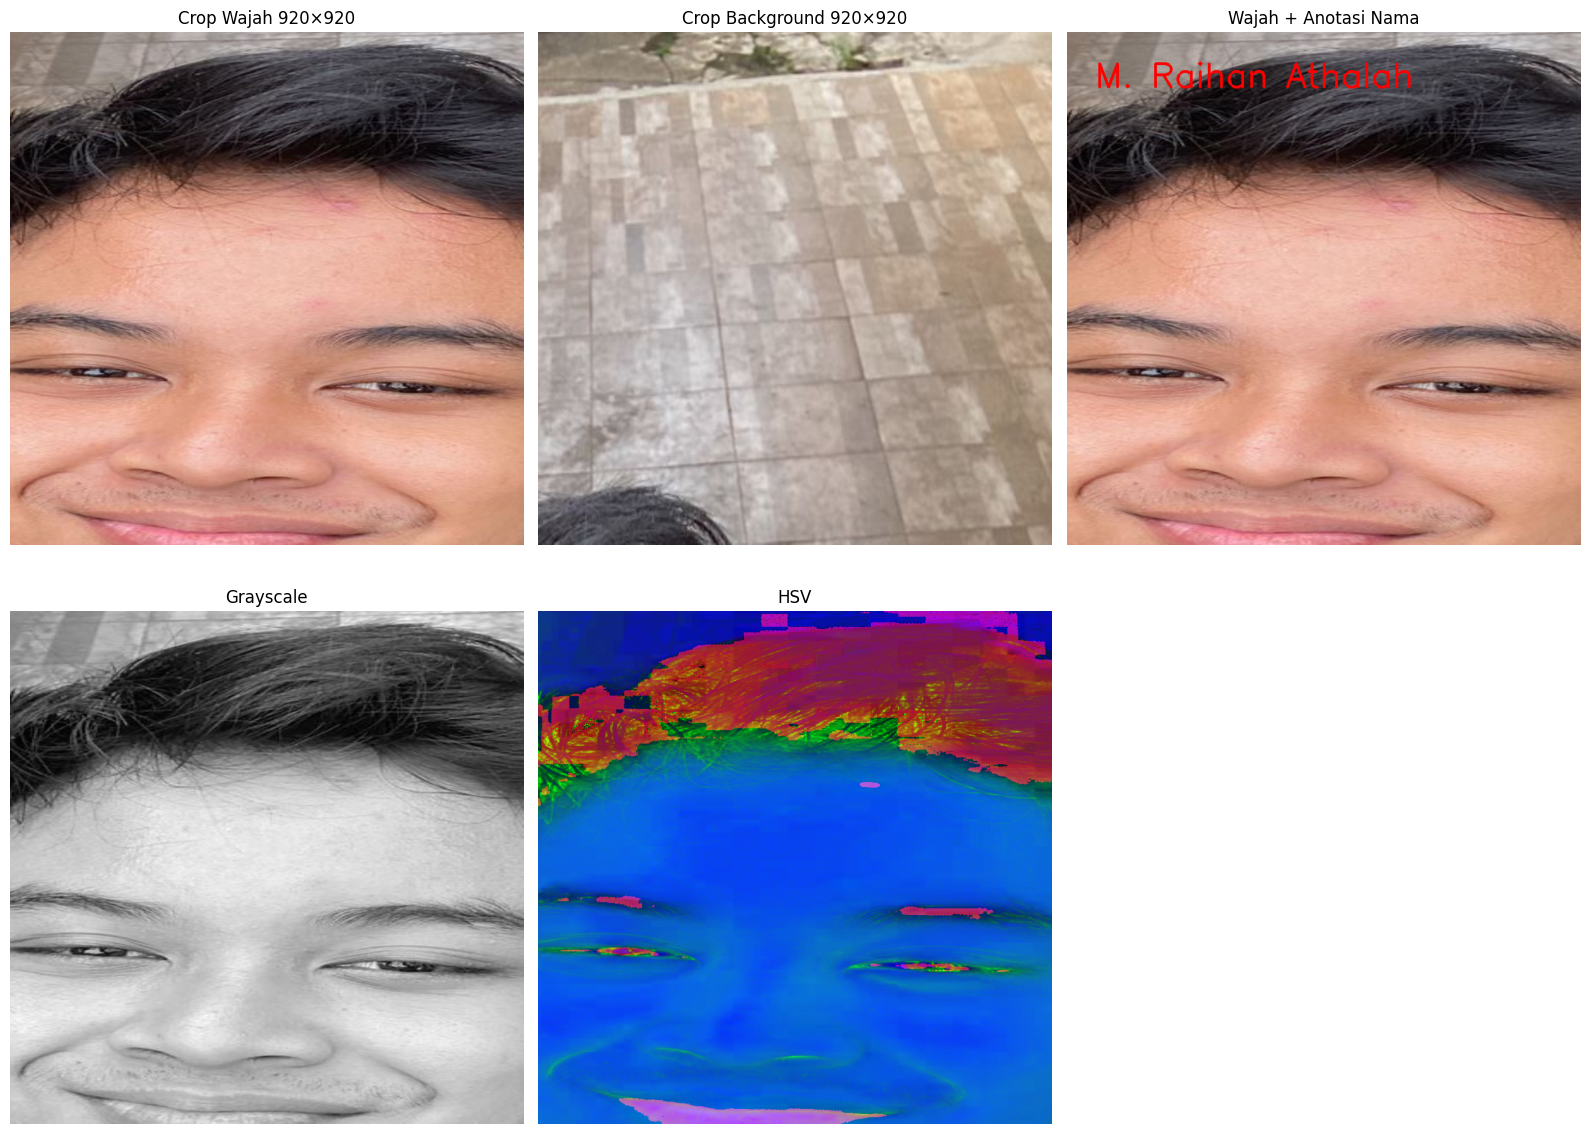

In [16]:
import cv2
import matplotlib.pyplot as plt

# --- 1. Load gambar ---
img = cv2.imread("/content/WhatsApp Image 2025-11-18 at 13.12.12_c404ec97.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- 2. Cropping manual ---
# Silakan ubah koordinat crop berikut sesuai posisi wajah dan background
# Format crop: img[y1:y2, x1:x2]

# Contoh: crop wajah (persegi)
face_crop = img_rgb[300:900, 350:650]


# Contoh: crop background (persegi panjang)
bg_crop = img_rgb[50:350, 500:900]

# --- 3. Resize hasil crop ke 920x920 ---
face_resized = cv2.resize(face_crop, (920, 920))
bg_resized = cv2.resize(bg_crop, (920, 920))

# --- 4. Konversi warna ---
gray = cv2.cvtColor(face_resized, cv2.COLOR_RGB2GRAY)
hsv  = cv2.cvtColor(face_resized, cv2.COLOR_RGB2HSV)

# --- 5. Tambahkan teks anotasi di atas kepala ---
annotated = face_resized.copy()
cv2.putText(
    annotated,
    "M. Raihan Athalah",        # teks
    (50, 100),                  # posisi teks (x, y)
    cv2.FONT_HERSHEY_SIMPLEX,   # font
    2,                           # ukuran
    (255, 0, 0),                 # warna (RGB)
    4                           # ketebalan
)

# --- 6. Tampilkan semua hasil ---
plt.figure(figsize=(16,12))

plt.subplot(2,3,1)
plt.imshow(face_resized)
plt.title("Crop Wajah 920×920")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(bg_resized)
plt.title("Crop Background 920×920")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(annotated)
plt.title("Wajah + Anotasi Nama")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.tight_layout()
plt.show()


1. Efek Cropping

Cropping wajah menghasilkan fokus yang lebih jelas pada objek utama (wajah).
Gangguan visual dari background dihilangkan sehingga objek lebih menonjol.

Cropping background memberikan area latar belakang yang lebih luas tanpa objek utama, berguna untuk analisis tekstur, warna, atau estetika background.

2. Efek Perubahan Warna
Grayscale

Mengubah gambar menjadi satu kanal intensitas cahaya.

Menghilangkan informasi warna sehingga lebih fokus pada bentuk, kontras, dan tekstur.

Banyak dipakai dalam deteksi wajah, tepi, dan preprocessing.

HSV (Hue, Saturation, Value)

Memisahkan warna menjadi:

Hue → jenis warna dasar,

Saturation → tingkat kejenuhan,

Value → kecerahan.

Membuat pengolahan warna lebih mudah karena tidak bergantung pada pencahayaan seperti RGB.

Cocok untuk segmentasi warna, deteksi objek berbasis warna, dan pemetaan warna.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


In [17]:
# Simpan hasil crop dari Soal 1 (misal face_resized)
cv2.imwrite("/content/face_crop_input.png", cv2.cvtColor(face_resized, cv2.COLOR_RGB2BGR))


True

Hasil disimpan di: /content/modified_rgb.png


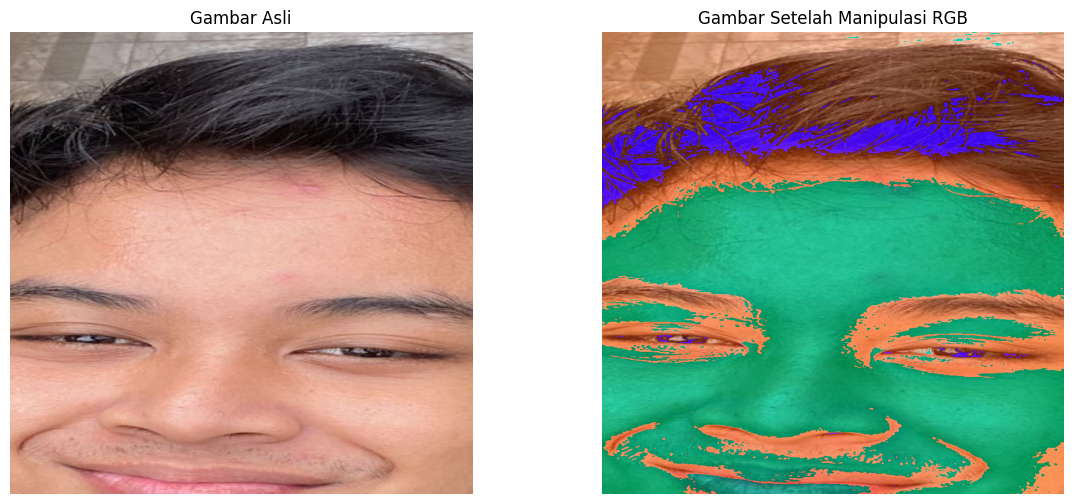

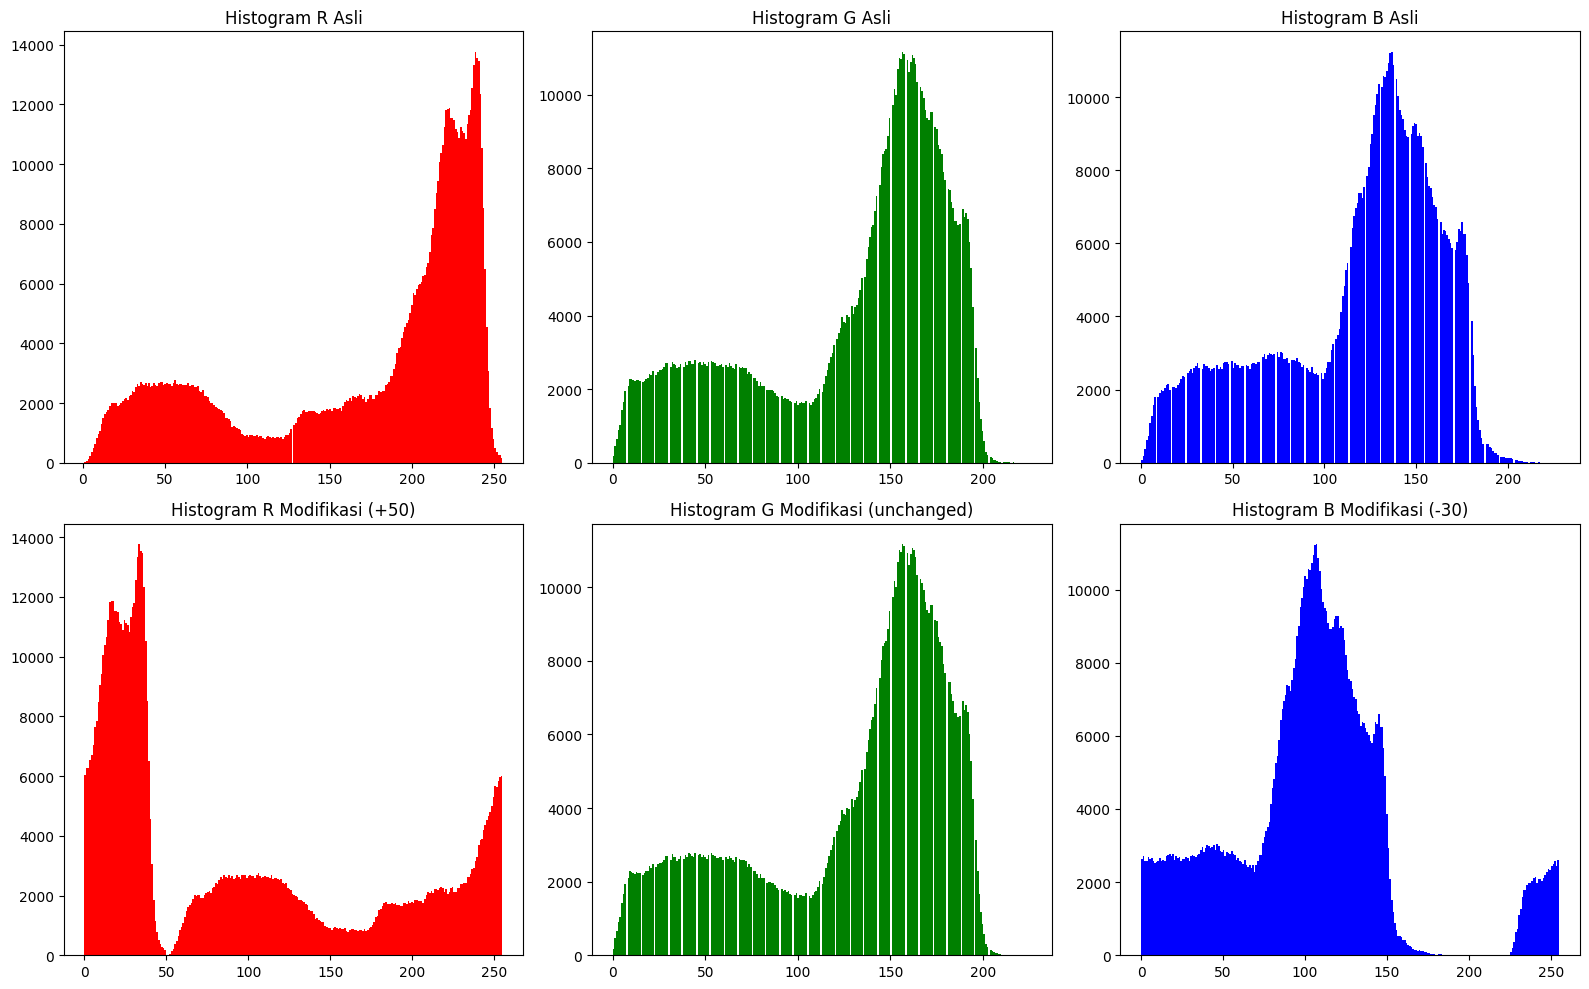

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load gambar hasil crop ---
img = cv2.imread("/content/face_crop_input.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Pisahkan channel
R, G, B = cv2.split(img_rgb)

# --- 2. Manipulasi channel ---
# Tambah red +50 (maks 255)
R_mod = np.clip(R + 50, 0, 255).astype(np.uint8)

# Kurangi blue -30 (min 0)
B_mod = np.clip(B - 30, 0, 255).astype(np.uint8)

# Green tidak diubah
G_mod = G.copy()

# --- 3. Gabungkan kembali ---
modified_rgb = cv2.merge([R_mod, G_mod, B_mod])

# --- 4. Simpan hasil ke PNG ---
save_path = "/content/modified_rgb.png"
cv2.imwrite(save_path, cv2.cvtColor(modified_rgb, cv2.COLOR_RGB2BGR))

print("Hasil disimpan di:", save_path)

# --- 5. Tampilkan gambar ---
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(modified_rgb)
plt.title("Gambar Setelah Manipulasi RGB")
plt.axis("off")
plt.show()

# --- 6. Tampilkan histogram per channel ---
plt.figure(figsize=(16,10))

# Hist asli
plt.subplot(2,3,1)
plt.hist(img_rgb[:,:,0].ravel(), bins=256, color='red')
plt.title("Histogram R Asli")

plt.subplot(2,3,2)
plt.hist(img_rgb[:,:,1].ravel(), bins=256, color='green')
plt.title("Histogram G Asli")

plt.subplot(2,3,3)
plt.hist(img_rgb[:,:,2].ravel(), bins=256, color='blue')
plt.title("Histogram B Asli")

# Hist modifikasi
plt.subplot(2,3,4)
plt.hist(modified_rgb[:,:,0].ravel(), bins=256, color='red')
plt.title("Histogram R Modifikasi (+50)")

plt.subplot(2,3,5)
plt.hist(modified_rgb[:,:,1].ravel(), bins=256, color='green')
plt.title("Histogram G Modifikasi (unchanged)")

plt.subplot(2,3,6)
plt.hist(modified_rgb[:,:,2].ravel(), bins=256, color='blue')
plt.title("Histogram B Modifikasi (-30)")

plt.tight_layout()
plt.show()


Dampak Manipulasi Channel RGB terhadap Warna Gambar
1. Red Channel (+50 poin)

Penambahan intensitas pada channel merah membuat gambar tampak lebih hangat.
Dampaknya:

Area kulit menjadi lebih merah atau pinkish.

Highlight tampak lebih terang karena merah adalah komponen kuat dalam pembentukan warna terang.

Histogram channel merah bergeser ke kanan, karena nilai pixel meningkat.

2. Blue Channel (−30 poin)

Pengurangan intensitas biru membuat warna gambar menjadi lebih kuning/oranye.
Hal ini karena:

Warna biru berkurang → komposisi warna bergerak ke arah kebalikan biru (yaitu kuning).

Shadow dan bagian gelap menjadi tampak lebih hangat.

Histogram channel biru bergeser ke kiri sebagai tanda penurunan intensitas.

3. Green Channel (tidak diubah)

Karena channel hijau tetap:

Stabilitas keseimbangan warna masih terjaga.

Tidak terjadi pergeseran drastis ke arah hijau.

Kesimpulan

Manipulasi sederhana pada channel RGB dapat mengubah mood dan tone gambar secara signifikan.
Gambar akhir menjadi:

Lebih hangat

Dominan merah-kuning

Kurang biru

Memiliki distribusi histogram yang bergeser sesuai manipulas

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


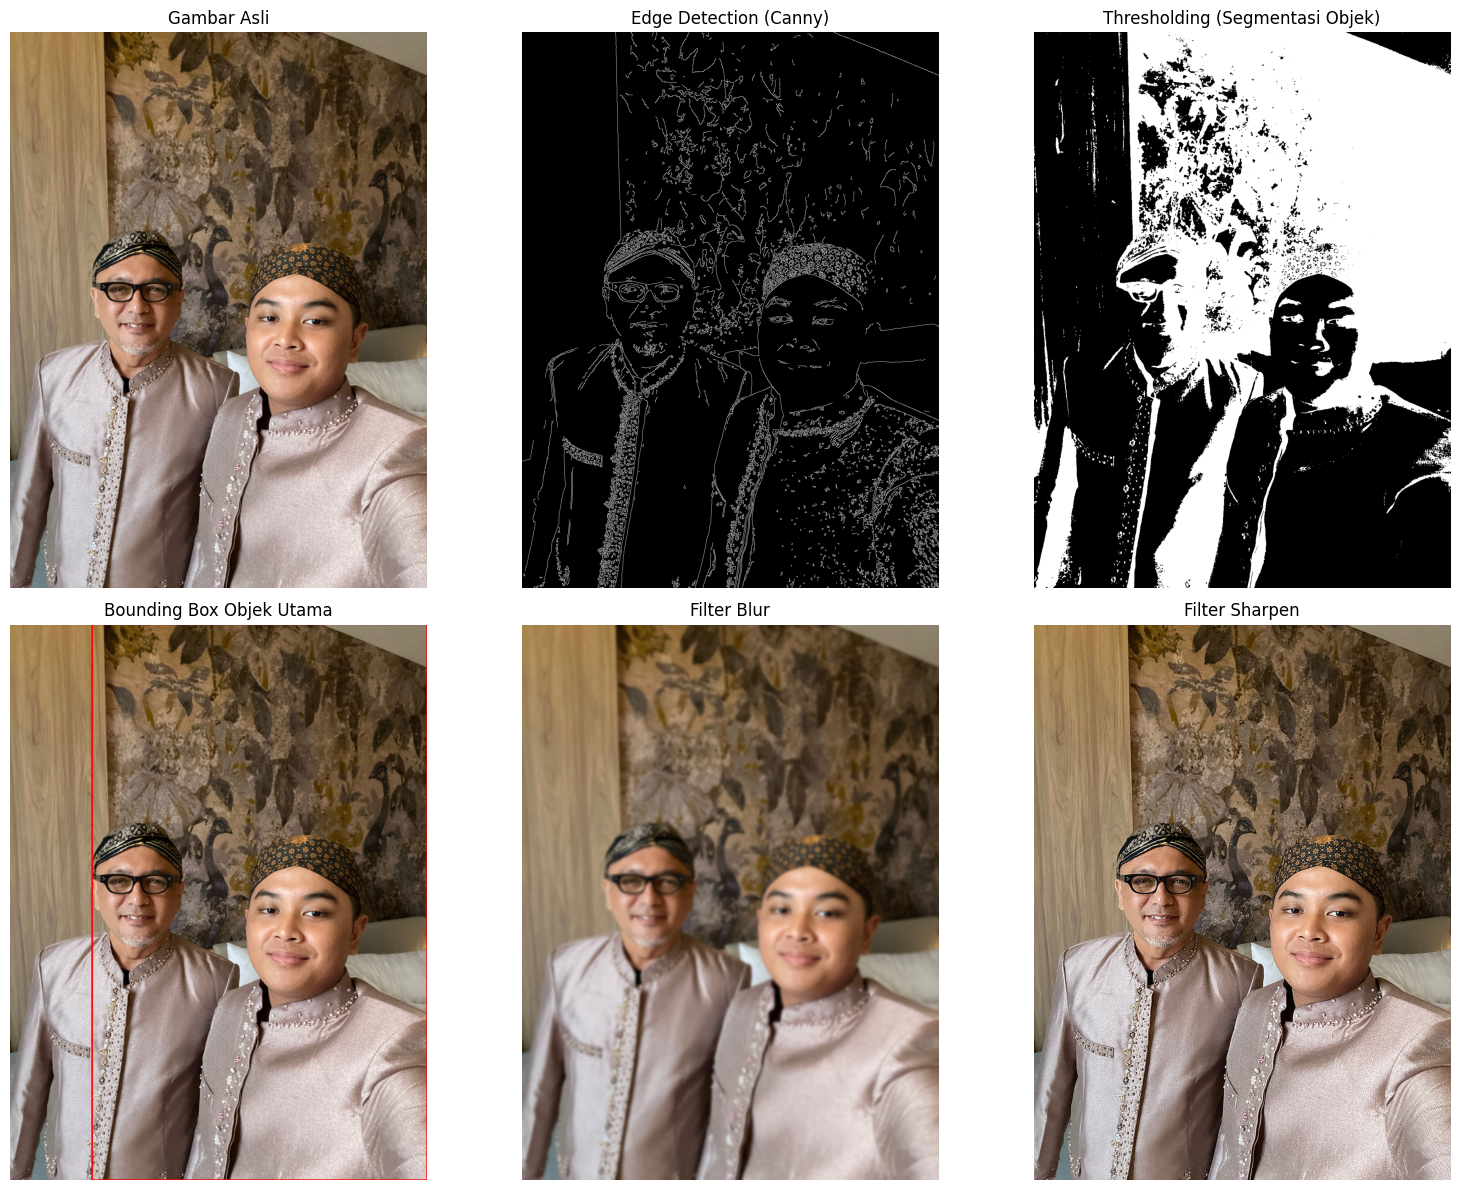

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar
path = "/content/WhatsApp Image 2025-11-18 at 13.20.07_c2cea847.jpg"
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Edge Detection (Canny)
edges = cv2.Canny(img, 100, 200)

# 3. Thresholding (mengambil objek utama)
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tentukan nilai threshold – bisa ubah sesuai objek
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

# 4. Temukan kontur dan buat bounding box otomatis
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

bbox_img = img_rgb.copy()

# Ambil kontur terbesar (diasumsikan objek utama)
if len(contours) > 0:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(bbox_img, (x, y), (x+w, y+h), (255, 0, 0), 4)

# 5. Filter Blur & Sharpen
blur = cv2.GaussianBlur(img_rgb, (21, 21), 0)

# Kernel sharpening
kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpen = cv2.filter2D(img_rgb, -1, kernel_sharp)

# 6. Tampilkan semua hasil
plt.figure(figsize=(16,12))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholding (Segmentasi Objek)")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bbox_img)
plt.title("Bounding Box Objek Utama")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(blur)
plt.title("Filter Blur")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(sharpen)
plt.title("Filter Sharpen")
plt.axis("off")

plt.tight_layout()
plt.show()


Dampak Edge Detection, Thresholding, Blur, dan Sharpen terhadap Detail Gambar
1. Edge Detection (Canny)

Metode Canny mendeteksi perbatasan antar objek berdasarkan perubahan intensitas piksel.
Efeknya:

Garis tepi objek terlihat jelas.

Detail tekstur pada background (misalnya motif kain atau batu) muncul sebagai garis halus.

Menghilangkan informasi warna dan fokus pada struktur bentuk.

2. Thresholding

Thresholding memisahkan objek dari background berdasarkan nilai piksel tertentu.
Dampaknya:

Hanya objek utama yang dipertahankan.

Background yang bertekstur menjadi area hitam putih polos sesuai ambang.

Membantu memudahkan pencarian kontur dan bounding box.

3. Filter Blur

Filter Gaussian Blur menghaluskan citra.
Efeknya:

Detail kecil pada permukaan objek dan background menghilang.

Noise dan tekstur tajam menjadi kabur.

Pinggiran objek menjadi lebih lembut dan kurang terdefinisi.

Cocok untuk smoothing sebelum edge detection atau segmentasi.

4. Filter Sharpen

Filter sharpening meningkatkan kontras tepi (detail).
Dampaknya:

Detail objek menjadi lebih tajam dan terlihat jelas.

Tekstur background bertekstur menjadi lebih kuat dan kontras.

Garis tepi objek menjadi lebih menonjol.

Citra terlihat lebih “tegas”, tetapi dapat menambah noise bila berlebihan.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

In [21]:
pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 9.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled pr

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


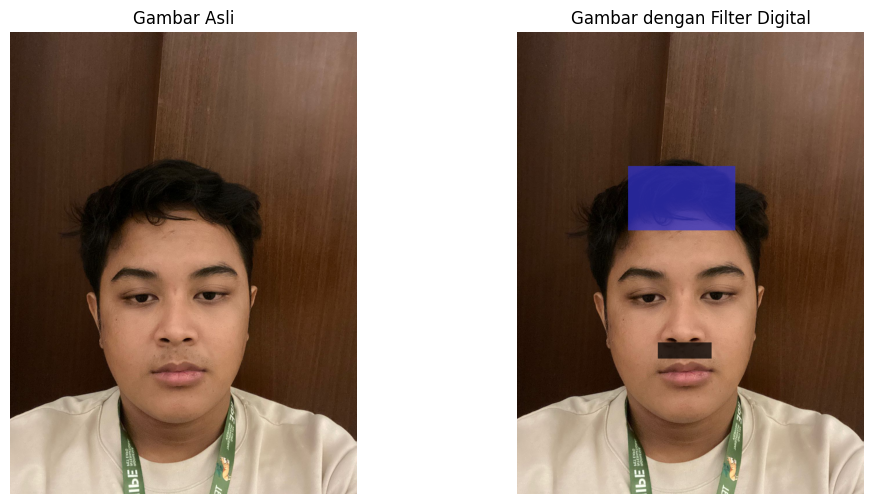

In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
path = "/content/WhatsApp Image 2025-11-18 at 13.23.44_07797b31.jpg"
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mp_face_mesh = mp.solutions.face_mesh
mp_draw = mp.solutions.drawing_utils

# FaceMesh untuk landmark
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1)

# Proses deteksi
results = face_mesh.process(img_rgb)
overlay_img = img_rgb.copy()

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = img_rgb.shape

        # =========================================================
        # 1. Landmark INDEX untuk FILTER
        # =========================================================
        nose_tip = face_landmarks.landmark[1]              # ujung hidung
        mouth_left = face_landmarks.landmark[61]           # kiri bibir
        mouth_right = face_landmarks.landmark[291]         # kanan bibir
        forehead = face_landmarks.landmark[10]             # titik dahi atas

        # Konversi ke koordinat pixel
        def to_px(landmark):
            return int(landmark.x * w), int(landmark.y * h)

        nose_x, nose_y = to_px(nose_tip)
        ml_x, ml_y = to_px(mouth_left)
        mr_x, mr_y = to_px(mouth_right)
        fh_x, fh_y = to_px(forehead)

        # =========================================================
        # 2. Membuat FILTER KUMIS
        # =========================================================
        mustache_width = abs(mr_x - ml_x)
        mustache_height = int(mustache_width * 0.3)

        # Posisi kumis tepat di bawah hidung
        mx1 = ml_x
        my1 = nose_y + 10
        mx2 = mr_x
        my2 = my1 + mustache_height

        # warna kumis (hitam)
        cv2.rectangle(overlay_img, (mx1, my1), (mx2, my2), (0, 0, 0), -1)

        # =========================================================
        # 3. Membuat FILTER TOPI
        # =========================================================
        hat_width = int(mustache_width * 2)
        hat_height = int(hat_width * 0.6)

        hx1 = fh_x - hat_width // 2
        hy1 = fh_y - hat_height - 40
        hx2 = fh_x + hat_width // 2
        hy2 = fh_y - 40

        cv2.rectangle(overlay_img, (hx1, hy1), (hx2, hy2), (50, 50, 200), -1)

        # =========================================================
        # 4. Alpha Blending
        # =========================================================
        alpha = 0.75
        blended = cv2.addWeighted(overlay_img, alpha, img_rgb, 1 - alpha, 0)

else:
    print("Wajah tidak terdeteksi.")
    blended = img_rgb

# =========================================================
# 5. Tampilkan hasil
# =========================================================
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blended)
plt.title("Gambar dengan Filter Digital")
plt.axis("off")

plt.show()


Penjelasan Perhitungan Posisi Overlay & Tantangan Implementasi
1. Deteksi Wajah dan Landmark

Saya menggunakan MediaPipe Face Mesh karena:

Akurat untuk landmark (468 titik wajah)

Stabil dan mudah digunakan

Memberi koordinat normalisasi (0–1) → dapat dikonversi ke piksel

2. Perhitungan Posisi Kumis

Lebar kumis = jarak antara kedua sudut bibir:
mustache_width = |mouth_right.x – mouth_left.x|

Tinggi kumis ditentukan proporsional:
mustache_height = mustache_width × 0.3

Posisi kumis diletakkan 10 piksel di bawah hidung:
my1 = nose_y + 10
my2 = my1 + mustache_height

3. Perhitungan Posisi Topi

Lebar topi = 2 × lebar kumis
Topi diletakkan di atas dahi:
hx1 = forehead_x – hat_width/2
hy1 = forehead_y – hat_height – 40

Offset 40 px digunakan agar jarak topi tampak natural.

4. Pembuatan Filter

Dua filter digambar manual menggunakan OpenCV:

Kumis → rectangle hitam

Topi → rectangle warna biru keunguan

Overlay bisa diganti PNG transparan jika diperlukan.

5. Alpha Blending

Digunakan untuk membuat filter tampak natural:
output = alpha * overlay + (1 - alpha) * original

Di sini digunakan nilai:
alpha = 0.75

Sehingga overlay tidak terlalu keras.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

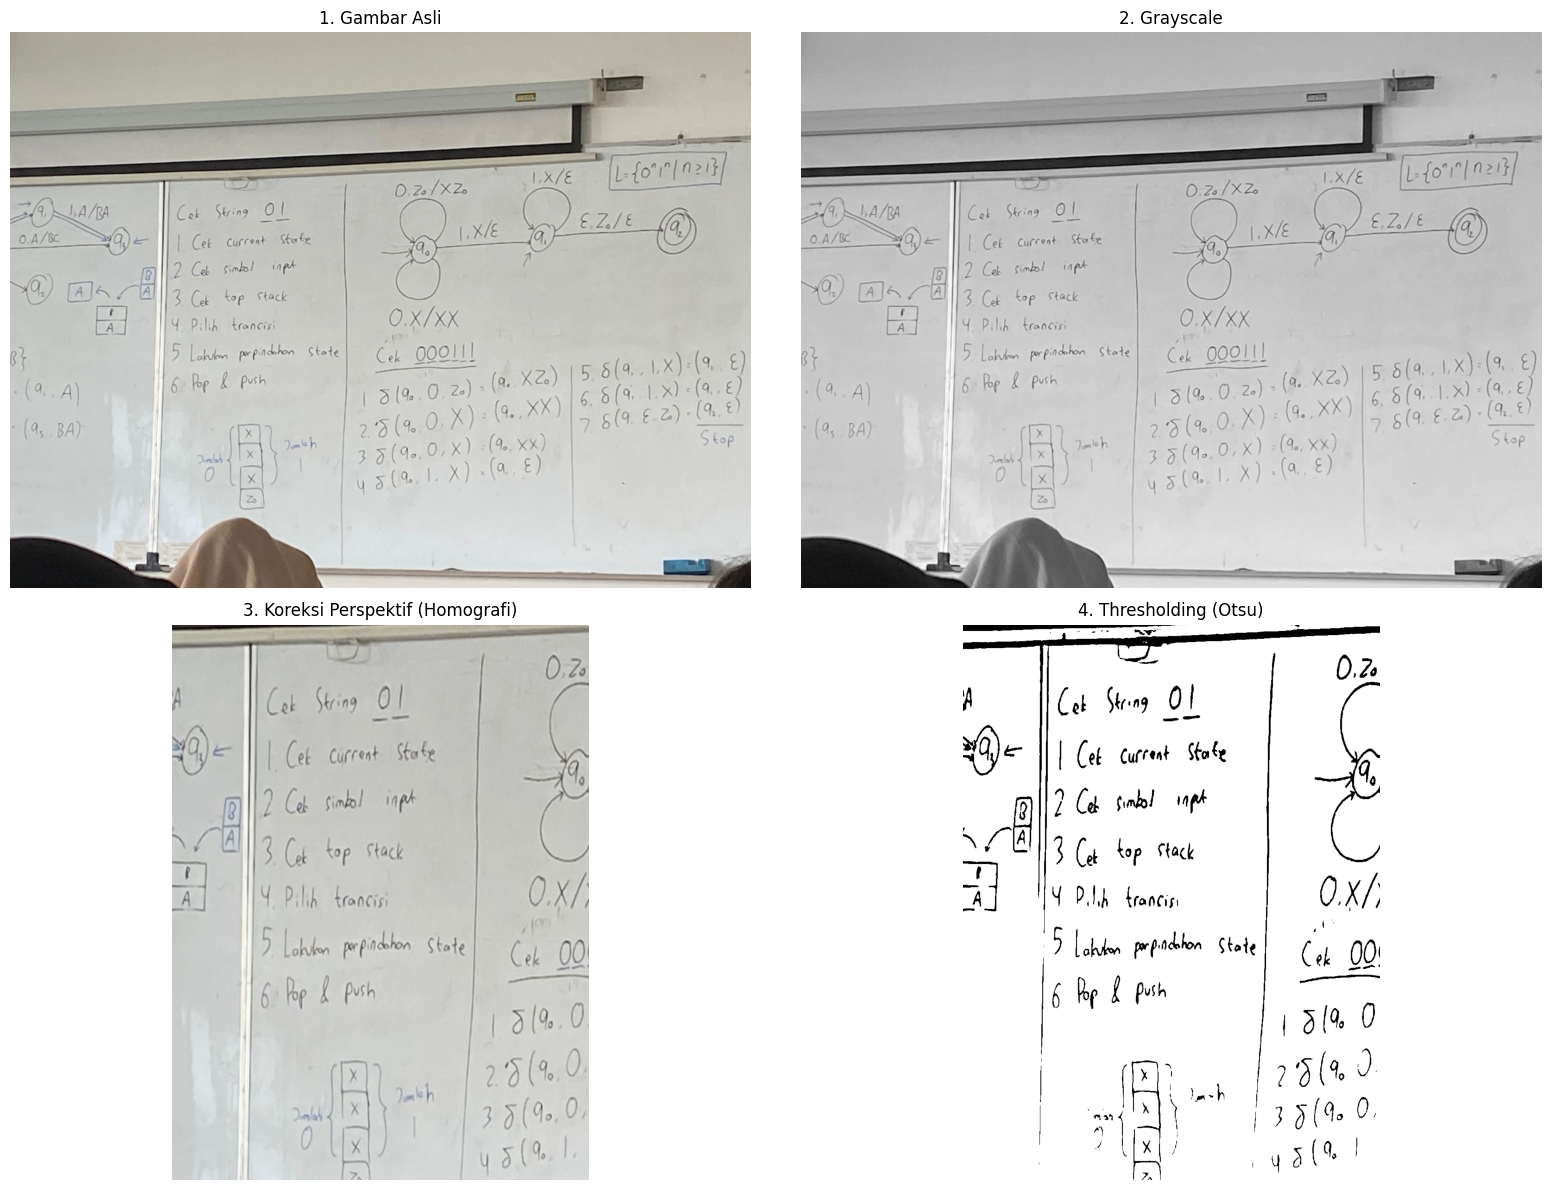

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Load dan grayscale
# ============================
path = "/content/WhatsApp Image 2025-11-18 at 13.30.33_10de4c72.jpg"
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ============================
# 2. Koreksi Perspektif (Homografi)
# ============================

pts_src = np.array([
    [200, 300],   # kiri atas
    [900, 290],   # kanan atas
    [950, 1000],  # kanan bawah
    [180, 1020]   # kiri bawah
], dtype=np.float32)

# Tentukan ukuran output (hasil rata)
width, height = 900, 1200
pts_dst = np.array([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
], dtype=np.float32)

# Homografi
H, _ = cv2.findHomography(pts_src, pts_dst)
warped = cv2.warpPerspective(img_rgb, H, (width, height))
warped_gray = cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY)

# ============================
# 3. Thresholding (Otsu)
# ============================
# Otsu bekerja sangat baik untuk dokumen karena background biasanya lebih cerah
_, otsu = cv2.threshold(
    warped_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# ============================
# 4. Tampilkan semua hasil
# ============================

plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("1. Gambar Asli")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("2. Grayscale")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(warped)
plt.title("3. Koreksi Perspektif (Homografi)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(otsu, cmap='gray')
plt.title("4. Thresholding (Otsu)")
plt.axis('off')

plt.tight_layout()
plt.show()


Penjelasan Tahap Preprocessing Gambar
1. Konversi ke Grayscale

Konversi ke grayscale mengubah citra RGB menjadi satu kanal intensitas.
Tujuan:

Mengurangi kompleksitas pemrosesan

Menghilangkan informasi warna yang tidak diperlukan

Mempermudah deteksi tepi atau thresholding

Grayscale merupakan langkah standar dalam preprocessing dokumen atau objek datar.

2. Koreksi Perspektif (Transformasi Homografi)

Pada foto kertas atau objek datar, sering terjadi:

Distorsi perspektif

Sudut tidak sejajar

Kemiringan (tilted)

Dengan memilih 4 titik sudut manual, transformasi homografi dapat:

Meluruskan objek

Mengubah tampilan miring menjadi tampak dari atas (top-down view)

Menghasilkan tampilan seperti hasil scan

Persamaan homografi menghitung matriks transformasi H yang memetakan 4 titik sumber (pts_src) ke 4 titik tujuan (pts_dst).

Hasilnya membuat dokumen jauh lebih mudah dibaca dan dianalisis.

3. Thresholding (Otsu)

Saya memilih metode Otsu dibanding thresholding adaptif karena:

Otsu bekerja sangat baik bila ada dua kelas piksel jelas (objek & background)

Cocok untuk kertas, papan tulis, atau gambar datar

Menentukan nilai threshold optimal secara otomatis

Otsu memaksimalkan separasi antara piksel foreground dan background sehingga:

Tulisan tampak lebih jelas

Noise pencahayaan ringan dapat dihilangkan

Kontras objek meningkat

4. Visualisasi dalam Grid

Semua tahap ditampilkan dalam satu grid 2×2 agar mudah dibandingkan:

Gambar Asli – kondisi miring / gelap

Grayscale – penyederhanaan data

Homografi – objek sudah lurus

Thresholding – hasil mirip scan dokumen

**Kesimpulan**

Dengan rangkaian preprocessing ini:

Perspektif yang salah dapat diperbaiki

Teks/objek menjadi lebih mudah dibaca

Gambar terlihat lebih profesional & rapi

Cocok untuk aplikasi seperti scanner dokumen, OCR, atau digitalisasi gambar

Link Bukti Chatgpt: https://chatgpt.com/c/691c0dda-1828-8323-8a22-196d86811444

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.